# Full Workflow

## Data Preparation

In [44]:
%load_ext autoreload
%autoreload 2
import numpy as np
import trimesh
from context import generationtools as gnt

#meshPath = r"../data\Monkey\MonkeyDebug.obj"
meshPath = r"../data\completionchair\CompletionChair.obj"
#meshPath = r"../data\bookcase.glb"
#meshPath = r"..\data\Complete_objects\CompleteCabinet.obj"
#meshPath = r"..\data\Complete_objects\CompleteSofa.obj"
#meshPath = r"..\data\Complete_objects\CompleteGardenChair.obj"
voxelResolution = 64 # The resolution of the voxelgrid

# load the mesh
mesh  = trimesh.load(meshPath, force='mesh')
meshName = meshPath.split('\\')[-1][:-4]
savePath = r"C:\Users\jelle\Documents\Unity\Geosharpi_Dev\Assets\DrmModels\Texture3Ds/" + meshName
# convert to SDF
print("Creating SDF")
sdf,normalized_mesh = gnt.mesh_to_sdf_tensor(gnt.as_mesh(mesh), voxelResolution, recenter=True, scaledownFactor=0.85)
# Get the colors
print("Sampling Colors")
voxel_grid = gnt.create_voxel_grid(voxelResolution, True)
colors = gnt.get_point_colors_trimesh(normalized_mesh, voxel_grid.reshape(-1,3),filter = (np.array(sdf)<=0.1).reshape(-1)).reshape(voxelResolution,voxelResolution,voxelResolution,4)
print("Done")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Creating SDF
Sampling Colors
Done


## Generating 3D Textures

Generated 3D texture with gridsize:(8, 8)


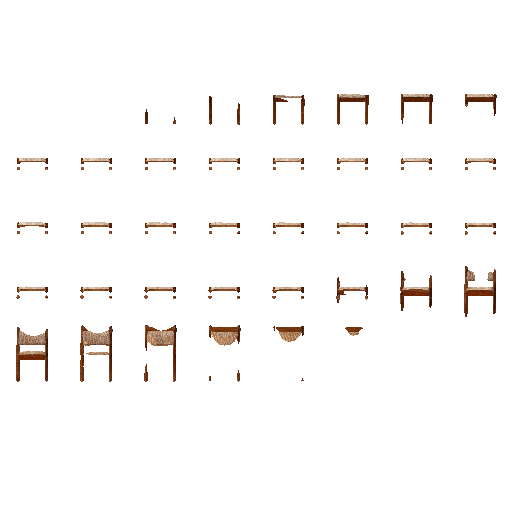

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

gridDim = int(np.ceil(np.sqrt(voxelResolution)))
#grid_size = (gridDim,gridDim)
grid_size = gnt.get_closest_factors(voxelResolution)
texture = gnt.create_tiled_texture(sdf, colors, grid_size)

# Save as an image
image = Image.fromarray(texture)
#image = image.transpose(Image.ROTATE_180) # rotate the image right side up
image.save(savePath + "_color_" + str(voxelResolution)+"_" +str(grid_size) + ".png")
print("Generated 3D texture with gridsize:" + str(grid_size))
# Display the image
display(image)



### Creating a SDF 3D Texture on a single channel

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def create_flipbook_texture(sdf_distances, grid_size):
    N, H, W = sdf_distances.shape
    
    # Normalize distance values to fit into the alpha channel (0-255)
    min_dist, max_dist = sdf_distances.min(), sdf_distances.max()
    sdf_distances = (sdf_distances - min_dist) / (max_dist - min_dist)
    
    # Store distances so that 255 represents the lowest distance (0) and 0 represents the max distance
    sdf_distances = (sdf_distances) * 255
    sdf_distances = sdf_distances.astype(np.uint8)
    
    # Create grayscale frames with distance in alpha channel
    rgba_frames = np.zeros((N, H, W,1), dtype=np.uint8)
    rgba_frames[..., 0] = sdf_distances  # Store distance in alpha channel
    
    # Arrange frames into a grid
    grid_rows, grid_cols = grid_size
    assert grid_rows * grid_cols >= N, "Grid size must be large enough to fit all slices"
    
    flipbook_height = grid_rows * H
    flipbook_width = grid_cols * W
    flipbook_texture = np.zeros((flipbook_height, flipbook_width, 4), dtype=np.uint8)
    
    for idx in range(N):
        row = idx // grid_cols
        col = idx % grid_cols
        y, x = row * H, col * W
        flipbook_texture[y:y+H, x:x+W, :] = rgba_frames[idx]
    
    return flipbook_texture

# Example usage
N, H, W = 64, 64, 64  # 16 slices of 64x64

grid_size = (8, 8)  # Arrange in a 4x4 grid
texture = create_flipbook_texture(sdf, grid_size)

# Save as an image
image = Image.fromarray(texture)
image.save(r"C:\Users\jelle\Documents\Unity\Geosharpi_Dev\Assets\DrmModels/sdf3D.png")
# Display the image
plt.imshow(texture)
plt.axis("off")
plt.show()


AssertionError: Grid size must be large enough to fit all slices

## Geomapi Texture3D Extension

In [23]:
#Texture3DNode
#IMPORT PACKAGES
from multiprocessing.sharedctypes import Value
import open3d as o3d 
import numpy as np 
from rdflib import Graph, URIRef
import os

#IMPORT MODULES
import geomapi
from geomapi.nodes import GeometryNode
import geomapi.utils as ut
import geomapi.utils.geometryutils as gmu
import rdflib
v4d=rdflib.Namespace('https://w3id.org/v4d/core#')
from rdflib import RDF, XSD, Graph, Literal, URIRef, FOAF

class Texture3DNode(geomapi.nodes.GeometryNode):
    def __init__(self,  graph : Graph = None, 
                        graphPath:str=None,
                        subject : URIRef = None,
                        path : str=None, 
                        getResource : bool = False,
                        **kwargs): 
        """
        Creates a MeshNode. Overloaded function.\n
        This Node can be initialised from one or more of the inputs below.\n
        By default, no data is imported in the Node to speed up processing.\n
        If you also want the data, call node.get_resource() or set getResource() to True.\n

        Args:\n
            0.graph (RDFlib Graph) : Graph with a single subject (if multiple subjects are present, only the first will be used to initialise the MeshNode)\n
            
            1.graphPath (str):  Graph file path with a single subject (if multiple subjects are present, only the first will be used to initialise the MeshNode)\n

            2.path (str) : path to mesh file (Note that this node will also contain the data)\n

            3.resource (o3d.geometry.TriangleMesh) : Open3D point cloud file (Note that this node will also contain the data)\n
                
            getResource (bool, optional= False): If True, the node will search for its physical resource on drive \n
            getMetaData (bool, optional= True): If True, the node will attempt to extract geometric metadata from the resource if present (cartesianBounds, etc.) \n
        
        Returns:
            A MeshNode with metadata
        """   
        #private attributes
        self.voxelResolution = None
        self.gridSize = None

        super().__init__(   graph= graph,
                            graphPath= graphPath,
                            subject= subject,
                            path=path,
                            **kwargs)        

        #initialisation functionality
        if getResource:
            self.get_resource() 


#---------------------METHODS----------------------------

    def set_resource(self, value): 
        """Set the self.resource (np.array) of the Node.\n

        Args:
            1. np.array()

        Raises:
            ValueError: Resource must be an an.array image.
        """
        if (isinstance(value, np.ndarray)):
            self._resource = value
        else:
            raise ValueError('Resource must be an tiled image np array')

    def get_resource(self)->np.array: 
        """Returns the image data in the node. \n
        If none is present, it will search for the data on drive from path, graphPath, name or subject. 

        Returns:
            o3d.geometry.TriangleMesh or None
        """
        if self._resource is not None:
            pass
        elif self.get_path():
            image = Image.open(self.path)
            self._resource = np.array(image)

        return self._resource  

    def save_resource(self, directory:str=None,extension :str = '.png') ->bool:
        """Export the resource of the Node.\n

        Args:
            directory (str, optional): directory folder to store the data.\n
            extension (str, optional): file extension. Defaults to '.png'.\n

        Raises:
            ValueError: Unsuitable extension. Please check permitted extension types in utils._init_.\n

        Returns:
            bool: return True if export was successful
        """         
        #check path
        if self.resource is None:
            return False
        
        #validate extension
        if extension not in ut.IMG_EXTENSION:
            raise ValueError('Invalid extension')

        # check if already exists
        if directory and os.path.exists(os.path.join(directory,self.name + extension)):
            self.path=os.path.join(directory,self.get_name() + extension)
            return True
        elif not directory and self.get_path() and os.path.exists(self.path) and extension in ut.IMG_EXTENSION:
            print("file already exists")
            return True
                    
        #get directory
        if (directory):
            pass    
        elif self.path is not None:    
            directory=ut.get_folder(self.path)            
        elif(self.graphPath): 
            dir=ut.get_folder(self.graphPath)
            directory=os.path.join(dir,'TEXTURE3D')   
        else:
            directory=os.path.join(os.getcwd(),'TEXTURE3D')
        # create directory if not present
        if not os.path.exists(directory):                        
            os.mkdir(directory) 

        self.path=os.path.join(directory,ut.get_filename(self.subject.toPython()) + extension)

        #write files
        image = Image.fromarray(self._resource)
        image = image.transpose(Image.ROTATE_180) # rotate the image right side up
        image.save(self.path)
        print("image saved at:" + self.path)

    def to_graph(self, graphPath : str = None, overwrite:bool=True,save:bool=False) -> Graph:
        """Converts the current Node variables to a graph and optionally save.

        Args:
            - graphPath (str, optional): The full path to write the graph to. Defaults to None.
            - overwrite (bool, optional=True): Overwrite current graph values or not
            - save (bool, optional=False): Save the graph to the self.graphPath or graphPath.
        """
        if graphPath and next(graphPath.endswith(extension) for extension in ut.RDF_EXTENSIONS) :
            self._graphPath=graphPath

        self._graph=Graph() 
        ut.bind_ontologies(self._graph)      
        nodeType=v4d[type(self).__name__]              
        self._graph.add((self.subject, RDF.type, nodeType ))  

        # enumerate attributes in node and write them to triples
        attributes = ut.get_variables_in_class(self)
        attributes = ut.clean_attributes_list(attributes)        
        pathlist = ut.get_paths_in_class(self)
                
        for attribute in attributes: 
            predicate = ut.match_uri(attribute)
            value=getattr(self,attribute)
            
            if value is not None:
                dataType=ut.get_data_type(value)
                temp=dataType.toPython()
                predtemp=predicate.toPython()

                if self._graph.value(self._subject, predicate, None)== str(value):
                    continue

                #check if exists
                elif overwrite:
                    self._graph.remove((self._subject, predicate, None))

                if 'linkedSubjects' in attribute:
                    if len(value) !=0:
                        value=[subject.toPython() for subject in self.linkedSubjects]
                    else:
                        continue
                
                elif attribute in pathlist:
                    if (self._graphPath):
                        folderPath=ut.get_folder_path(self.graphPath)
                        try:
                            value=os.path.relpath(value,folderPath)
                        except:
                            pass
                if 'string' not in dataType.toPython():        
                    self._graph.add((self._subject, predicate, Literal(value,datatype=dataType)))
                else:
                    self._graph.add((self._subject, predicate, Literal(value)))

        #Save graph
        if(save):
            self.save_graph(graphPath)            
        return self._graph


            



### Creating and saving Texture3DNode

In [26]:
newNode = Texture3DNode(path=savePath + "_color_" + str(voxelResolution)+"_" + str(grid_size)+".png")
newNode.set_resource(texture)
newNode.cartesianTransform = np.array((1,1,1))
newNode.voxelResolution = voxelResolution
newNode.gridSize = np.array(grid_size)
newNode.save_resource()
graph = newNode.to_graph(graphPath=savePath + "_color_" + str(voxelResolution)+"_" + str(grid_size)+".ttl", save=True)

print(graph)

file already exists
[a rdfg:Graph;rdflib:storage [a rdflib:Store;rdfs:label 'Memory']].
